#Emotion Classification with BERT

In [1]:
!pip install transformers hazm tqdm

import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU available: {gpu_name}")
    !nvidia-smi
else:
    print("Please enable GPU: Runtime -> Change runtime type -> T4 GPU")

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of hazm to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
GPU available: Tesla T4
Sat Mar  7 22:52:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07        

In [2]:

import sys
import os
from datetime import datetime
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [3]:
IN_COLAB = True
log_data = []

def log_to_csv(message, level="INFO"):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    log_data.append({"timestamp": timestamp, "level": level, "message": str(message)})
    print(f"{timestamp} - {level} - {message}")

def save_log_to_csv(save_path):
    log_df = pd.DataFrame(log_data)
    log_df.to_csv(save_path, index=False)
    print(f"Log data saved to {save_path}")

# Text preprocessing for Persian
try:
    from hazm import Normalizer
    hazm_normalizer = Normalizer()
    def preprocess_text(text):
        return hazm_normalizer.normalize(text) if isinstance(text, str) else text
    print("Hazm normalizer loaded successfully")
except ImportError:
    print("Hazm not installed, using basic preprocessing")
    def preprocess_text(text):
        return text

Hazm not installed, using basic preprocessing


In [4]:

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues, save_path=None):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Confusion matrix saved to {save_path}")
    plt.show()

def plot_training_loss(losses, save_path=None):
    plt.figure(figsize=(8, 5))
    plt.plot(losses, label='Training Loss', marker='o')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path)
        print(f"Training loss plot saved to {save_path}")
    plt.show()

In [5]:

def predict_emotion(sentences, model, tokenizer, device, max_len=256, labelencoder=None):
    model.eval()
    sentences = [preprocess_text(sentence) for sentence in sentences]
    inputs = tokenizer(sentences, add_special_tokens=True, max_length=max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        with autocast():
            logits = model(input_ids, attention_mask=attention_mask)[0]
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    if labelencoder:
        preds = labelencoder.inverse_transform(preds)

    return preds, probs

In [6]:
from google.colab import files
import os

!mkdir -p /content/input

print("Please upload your data files (train.txt, test.txt, val.txt)")
print("You can upload multiple files at once")
uploaded = files.upload()

for filename in uploaded.keys():
    !mv "{filename}" /content/input/
    print(f"Moved {filename} to /content/input/")

print("\nFiles in input directory:")
!ls /content/input/

Please upload your data files (train.txt, test.txt, val.txt)
You can upload multiple files at once


Saving test.txt to test.txt
Saving train.txt to train.txt
Saving val.txt to val.txt
Moved test.txt to /content/input/
Moved train.txt to /content/input/
Moved val.txt to /content/input/

Files in input directory:
test.txt  train.txt  val.txt


In [7]:
class Args:
    def __init__(self):
        self.data_path = '/content/input/'
        self.model_name = 'bert-base-multilingual-cased'  # برای پشتیبانی از فارسی
        self.batch_size = 16  # بهینه برای T4 GPU
        self.max_len = 256
        self.epochs = 3
        self.lr = 2e-5
        self.adam_epsilon = 1e-8
        self.num_warmup_steps = 0
        self.test_size = 0.1
        self.seed = 19
        self.early_stopping_patience = 2

args = Args()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared")

GPU memory cleared


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = args.seed
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    df_train = pd.read_csv(os.path.join(args.data_path, 'train.txt'), delimiter=';',
                           header=None, names=['sentence', 'label'])
    df_test = pd.read_csv(os.path.join(args.data_path, 'test.txt'), delimiter=';',
                          header=None, names=['sentence', 'label'])
    df_val = pd.read_csv(os.path.join(args.data_path, 'val.txt'), delimiter=';',
                         header=None, names=['sentence', 'label'])
    df = pd.concat([df_train, df_test, df_val], ignore_index=True)
    df['sentence'] = df['sentence'].apply(preprocess_text)

    print(f"Data loaded successfully:")
    print(f"Train: {len(df_train)}, Test: {len(df_test)}, Val: {len(df_val)}")
    print(f"Total: {len(df)}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise

print("\nLabel distribution:")
print(df['label'].value_counts())

labelencoder = LabelEncoder()
df['label_enc'] = labelencoder.fit_transform(df['label'])
df.rename(columns={'label': 'label_desc', 'label_enc': 'label'}, inplace=True)

print("\nEncoded labels:")
print(df[['label', 'label_desc']].drop_duplicates().sort_values('label'))

Using device: cuda
Data loaded successfully:
Train: 16000, Test: 2000, Val: 2000
Total: 20000

Label distribution:
label
joy         6761
sadness     5797
anger       2709
fear        2373
love        1641
surprise     719
Name: count, dtype: int64

Encoded labels:
   label label_desc
2      0      anger
7      1       fear
8      2        joy
3      3       love
0      4    sadness
6      5   surprise


In [9]:
tokenizer = BertTokenizer.from_pretrained(args.model_name,
                                         do_lower_case=args.model_name.endswith('uncased'))

print("Tokenizing sentences...")
inputs = tokenizer(df.sentence.values.tolist(),
                   add_special_tokens=True,
                   max_length=args.max_len,
                   padding='max_length',
                   truncation=True,
                   return_tensors='pt')

input_ids = inputs['input_ids']
attention_masks = inputs['attention_mask']
labels = torch.tensor(df.label.values)

print(f"Input shape: {input_ids.shape}")
print(f"Sample sentence: {df.sentence.values[0]}")
print(f"Tokenized length: {len(input_ids[0])}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing sentences...
Input shape: torch.Size([20000, 256])
Sample sentence: i didnt feel humiliated
Tokenized length: 256


In [10]:
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, labels, random_state=41, test_size=args.test_size)
train_masks, validation_masks, _, _ = train_test_split(
    attention_masks, input_ids, random_state=41, test_size=args.test_size)

train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(
    train_data,
    sampler=RandomSampler(train_data),
    batch_size=args.batch_size
)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_dataloader = DataLoader(
    validation_data,
    sampler=SequentialSampler(validation_data),
    batch_size=args.batch_size
)

print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(validation_dataloader)}")

Train batches: 1125
Validation batches: 125


In [11]:
model = BertForSequenceClassification.from_pretrained(
    args.model_name,
    num_labels=len(labelencoder.classes_)
).to(device)

scaler = GradScaler()

optimizer = AdamW(model.parameters(), lr=args.lr, eps=args.adam_epsilon)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=args.num_warmup_steps,
    num_training_steps=len(train_dataloader) * args.epochs
)

print(f"Model loaded. Number of labels: {len(labelencoder.classes_)}")
print(f"Labels: {labelencoder.classes_}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Number of labels: 6
Labels: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']



Epoch 1/3


Training:   0%|          | 0/1125 [00:00<?, ?it/s]

Average training loss: 0.7430
Validation accuracy: 0.9085
Confusion matrix saved to /content/confusion_matrix_epoch_1.png


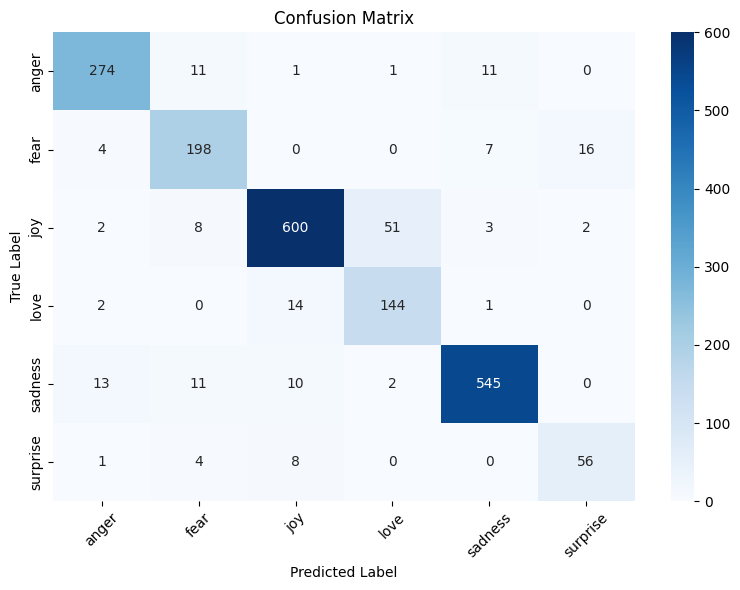

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved! Accuracy: 0.9085

Epoch 2/3


Training:   0%|          | 0/1125 [00:00<?, ?it/s]

Average training loss: 0.2071
Validation accuracy: 0.9250
Confusion matrix saved to /content/confusion_matrix_epoch_2.png


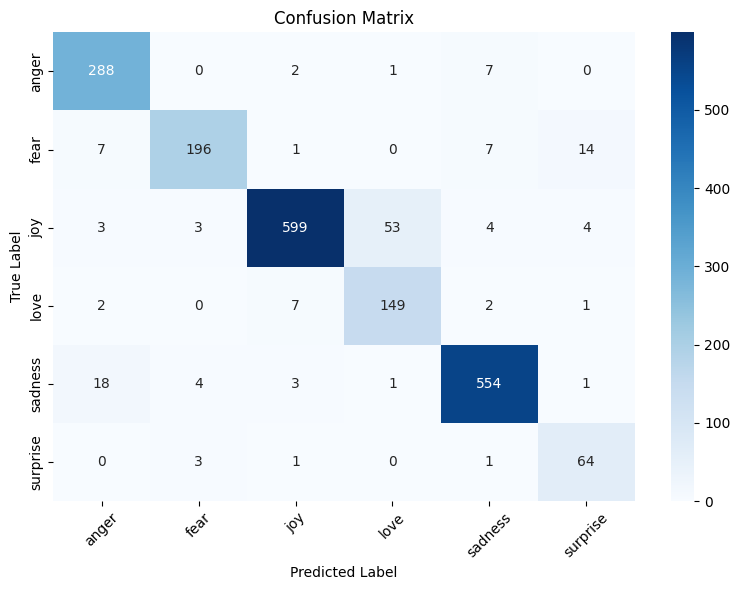

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved! Accuracy: 0.9250

Epoch 3/3


Training:   0%|          | 0/1125 [00:00<?, ?it/s]

Average training loss: 0.1395
Validation accuracy: 0.9270
Confusion matrix saved to /content/confusion_matrix_epoch_3.png


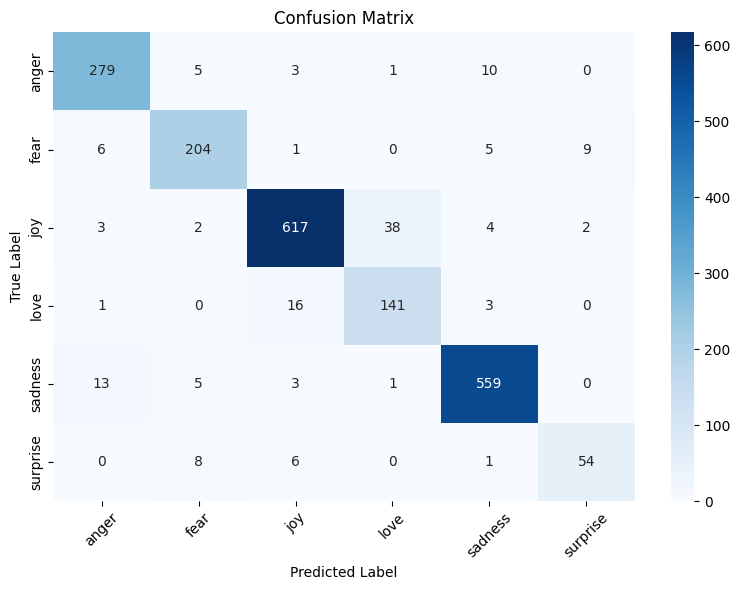

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved! Accuracy: 0.9270


In [12]:
train_loss_set = []
best_val_accuracy = 0.0
early_stopping_counter = 0
metrics_log = []

for epoch in range(args.epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{args.epochs}")
    print(f"{'='*50}")

    # Training
    model.train()
    batch_loss = 0

    progress_bar = tqdm(train_dataloader, desc='Training')
    for batch in progress_bar:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with autocast():
            outputs = model(b_input_ids, token_type_ids=None,
                          attention_mask=b_input_mask, labels=b_labels)
            loss = outputs[0]

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

        batch_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

        torch.cuda.empty_cache()

    avg_train_loss = batch_loss / len(train_dataloader)
    train_loss_set.append(avg_train_loss)
    print(f"Average training loss: {avg_train_loss:.4f}")

    # Validation
    model.eval()
    eval_accuracy = 0
    nb_eval_steps = 0
    all_preds, all_labels = [], []

    for batch in validation_dataloader:
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            with autocast():
                logits = model(b_input_ids, token_type_ids=None,
                             attention_mask=b_input_mask)

        logits = logits[0].to('cpu').numpy()
        label_ids = b_labels.to('cpu').numpy()
        pred_flat = np.argmax(logits, axis=1).flatten()
        labels_flat = label_ids.flatten()

        all_preds.extend(pred_flat)
        all_labels.extend(labels_flat)
        eval_accuracy += accuracy_score(labels_flat, pred_flat)
        nb_eval_steps += 1

        torch.cuda.empty_cache()

    avg_val_accuracy = eval_accuracy / nb_eval_steps
    print(f"Validation accuracy: {avg_val_accuracy:.4f}")

    metrics_log.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_accuracy': avg_val_accuracy
    })

    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, labelencoder.classes_,
                         save_path=f'/content/confusion_matrix_epoch_{epoch+1}.png')


    if avg_val_accuracy > best_val_accuracy:
        best_val_accuracy = avg_val_accuracy
        model.save_pretrained('/content/best_model/')
        tokenizer.save_pretrained('/content/best_model/')
        print(f"Best model saved! Accuracy: {best_val_accuracy:.4f}")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= args.early_stopping_patience:
            print(f"Early stopping triggered after {epoch + 1} epochs")
            break

Training loss plot saved to /content/training_loss.png


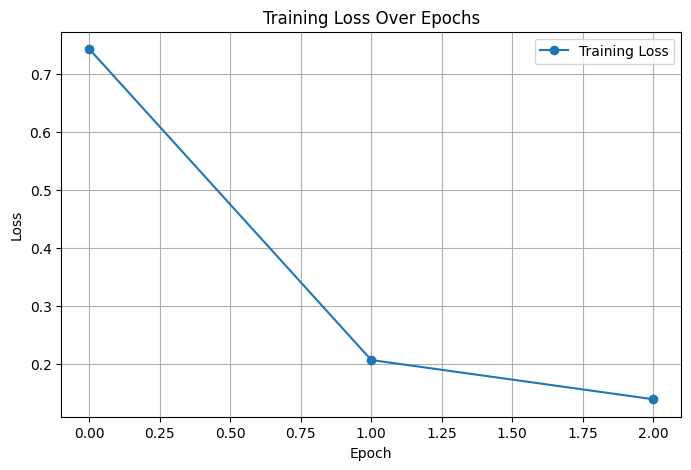

Training metrics saved to /content/training_metrics.csv
   epoch  train_loss  val_accuracy
0      1    0.743045        0.9085
1      2    0.207099        0.9250
2      3    0.139465        0.9270


In [13]:
plot_training_loss(train_loss_set, save_path='/content/training_loss.png')

metrics_df = pd.DataFrame(metrics_log)
metrics_df.to_csv('/content/training_metrics.csv', index=False)
print("Training metrics saved to /content/training_metrics.csv")
print(metrics_df)

In [14]:
final_output_dir = '/content/final_model/'
os.makedirs(final_output_dir, exist_ok=True)
model.save_pretrained(final_output_dir)
tokenizer.save_pretrained(final_output_dir)
print(f"Final model saved to {final_output_dir}")

# Zip models for download
!zip -r /content/best_model.zip /content/best_model/
!zip -r /content/final_model.zip /content/final_model/

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to /content/final_model/
  adding: content/best_model/ (stored 0%)
  adding: content/best_model/model.safetensors (deflated 7%)
  adding: content/best_model/tokenizer_config.json (deflated 43%)
  adding: content/best_model/tokenizer.json (deflated 67%)
  adding: content/best_model/config.json (deflated 58%)
  adding: content/final_model/ (stored 0%)
  adding: content/final_model/model.safetensors (deflated 7%)
  adding: content/final_model/tokenizer_config.json (deflated 43%)
  adding: content/final_model/tokenizer.json (deflated 67%)
  adding: content/final_model/config.json (deflated 58%)


In [17]:
sample_sentences = [
    "I am so happy today",
    "This is very sad news",
    "من امروز خیلی خوشحالم",  # Persian
]

print("Sample predictions:")
preds, probs = predict_emotion(sample_sentences, model, tokenizer, device,
                               args.max_len, labelencoder)

for sentence, pred, prob in zip(sample_sentences, preds, probs):
    print(f"\nSentence: {sentence}")
    print(f"Predicted emotion: {pred}")
    print(f"Probabilities: {dict(zip(labelencoder.classes_, prob))}")

Sample predictions:

Sentence: I am so happy today
Predicted emotion: joy
Probabilities: {'anger': np.float16(0.0001108), 'fear': np.float16(0.0001016), 'joy': np.float16(0.9995), 'love': np.float16(0.0001081), 'sadness': np.float16(0.0001382), 'surprise': np.float16(0.0001191)}

Sentence: This is very sad news
Predicted emotion: sadness
Probabilities: {'anger': np.float16(0.010155), 'fear': np.float16(0.000646), 'joy': np.float16(0.001327), 'love': np.float16(0.0001478), 'sadness': np.float16(0.9873), 'surprise': np.float16(0.0003057)}

Sentence: من امروز خیلی خوشحالم
Predicted emotion: joy
Probabilities: {'anger': np.float16(0.008545), 'fear': np.float16(0.02776), 'joy': np.float16(0.886), 'love': np.float16(0.0003529), 'sadness': np.float16(0.00594), 'surprise': np.float16(0.0714)}


In [16]:
from google.colab import files

log_csv_path = f"/content/training_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
save_log_to_csv(log_csv_path)

print("\nFiles available for download:")
!ls -lh /content/*.csv /content/*.png /content/*.zip

# Download files (uncomment to download)
files.download('/content/training_metrics.csv')
files.download('/content/training_loss.png')
files.download('/content/best_model.zip')
files.download('/content/final_model.zip')

Log data saved to /content/training_log_20260307_231603.csv

Files available for download:
-rw-r--r-- 1 root root 631M Mar  7 23:15 /content/best_model.zip
-rw-r--r-- 1 root root  39K Mar  7 23:01 /content/confusion_matrix_epoch_1.png
-rw-r--r-- 1 root root  38K Mar  7 23:08 /content/confusion_matrix_epoch_2.png
-rw-r--r-- 1 root root  40K Mar  7 23:14 /content/confusion_matrix_epoch_3.png
-rw-r--r-- 1 root root 631M Mar  7 23:16 /content/final_model.zip
-rw-r--r-- 1 root root    1 Mar  7 23:16 /content/training_log_20260307_231603.csv
-rw-r--r-- 1 root root  29K Mar  7 23:14 /content/training_loss.png
-rw-r--r-- 1 root root  113 Mar  7 23:14 /content/training_metrics.csv
